In [34]:
#!pip install numpy pandas matplotlib

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import copy

   City   X   Y  Frequency
0     0  37  52          7
1     1  49  49         30
2     2  52  64         16
3     3  20  26          9
4     4  40  30         21


C:\Users\Sanjana\AppData\Local\Temp\ipykernel_29880\1788821353.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filepath, delim_whitespace=True, header=None, names=['City', 'X', 'Y', 'Frequency'])


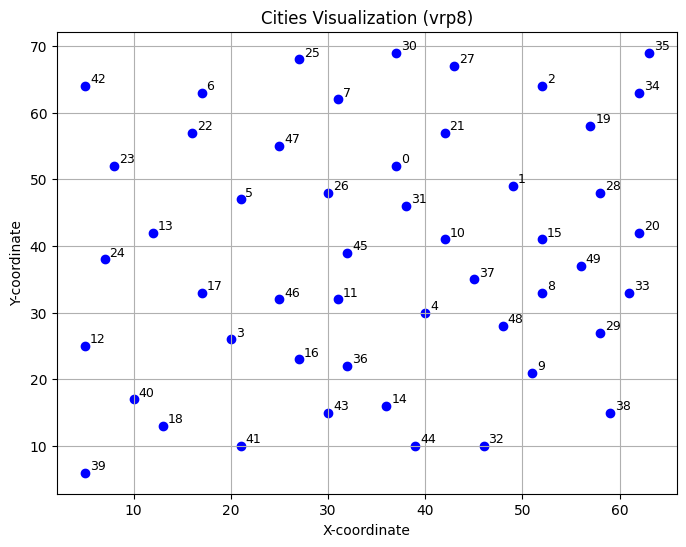

[[ 0.         12.36931688 19.20937271 ... 12.36931688 26.40075756
  24.20743687]
 [12.36931688  0.         15.29705854 ... 24.73863375 21.02379604
  13.89244399]
 [19.20937271 15.29705854  0.         ... 28.46049894 36.22154055
  27.29468813]
 ...
 [12.36931688 24.73863375 28.46049894 ...  0.         35.4682957
  35.84689666]
 [26.40075756 21.02379604 36.22154055 ... 35.4682957   0.
  12.04159458]
 [24.20743687 13.89244399 27.29468813 ... 35.84689666 12.04159458
   0.        ]]


In [49]:
# Function to load data from file
def load_vrp_data(filepath):
    data = pd.read_csv(filepath, delim_whitespace=True, header=None, names=['City', 'X', 'Y', 'Frequency'])
    data = data.dropna()
    data['City'] = data['City'] - 1
    data['Frequency'] = data['Frequency'].astype(int)
    return data

vrp8 = load_vrp_data('vrp8.txt')
print(vrp8.head())

# Visualize city locations
def plot_cities(data, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(data['X'], data['Y'], c='blue')
    for i, row in data.iterrows():
        plt.text(row['X']+0.5, row['Y']+0.5, str(int(row['City'])), fontsize=9)
    plt.xlabel('X-coordinate')
    plt.ylabel('Y-coordinate')
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_cities(vrp8, 'Cities Visualization (vrp8)')

# Calculate Euclidean distance matrix
def calculate_distance_matrix(data):
    coords = data[['X', 'Y']].values
    num_cities = coords.shape[0]
    distance_matrix = np.zeros((num_cities, num_cities))
    for i in range(num_cities):
        for j in range(num_cities):
            distance_matrix[i, j] = np.linalg.norm(coords[i] - coords[j])
    return distance_matrix

distance_matrix = calculate_distance_matrix(vrp8)
print(distance_matrix)


In [50]:
def evaluate_fitness(solution, distance_matrix, w_distance=0.7, w_balance=0.3):
    period_distances = []

    # Calculate distance per period
    for route in solution.values():
        if len(route) <= 1:
            continue
        distance = sum(distance_matrix[route[i]][route[i+1]] for i in range(len(route)-1))
        period_distances.append(distance)

    if len(period_distances) == 0:
        return float('inf'), float('inf'), float('inf')

    total_distance = sum(period_distances)
    workload_variance = np.var(period_distances)

    fitness = w_distance * total_distance + w_balance * workload_variance

    return fitness, total_distance, workload_variance


# def evaluate_fitness(solution, distance_matrix, w_distance=0.7, w_balance=0.3):
#     period_distances = []

#     for route in solution.values():
#         if len(route) <= 1:
#             continue
#         try:
#             distance = sum(distance_matrix[route[i]][route[i+1]] for i in range(len(route)-1))
#             period_distances.append(distance)
#         except IndexError as e:
#             print("ROUTE ERROR:", route)
#             raise e

#     if len(period_distances) == 0:
#         return float('inf')

#     total_distance = sum(period_distances)
#     workload_variance = np.var(period_distances)
#     fitness = w_distance * total_distance + w_balance * workload_variance

#     return fitness


In [51]:
# ========== PARAMETERS ==========
population_size = 200
generations = 1500
num_periods = 7
depot = 0  # Assuming city 0 is depot
crossover_rate = 0.8
mutation_rate = 0.2
tournament_size = 3
elitism_size = 2

# City frequencies
city_frequencies = vrp8['Frequency'].tolist()
cities = list(range(len(city_frequencies)))

# ========== FUNCTIONS ==========

# Create an individual (a feasible assignment and tour)
def create_individual():
    individual = {f'Period_{i+1}': [] for i in range(num_periods)}  # Start empty
    visits_remaining = city_frequencies.copy()
    available_periods = {city: list(range(num_periods)) for city in cities}

    for city, freq in enumerate(visits_remaining):
        for _ in range(freq):
            if available_periods[city]:
                period = random.choice(available_periods[city])
                individual[f'Period_{period+1}'].append(city)
                available_periods[city].remove(period)

    # Now add depot at start and end properly
    for period in individual:
        middle_cities = individual[period]
        random.shuffle(middle_cities)  # Shuffle visiting order
        individual[period] = [depot] + middle_cities + [depot]  # Add depot at beginning and end

    return individual

def tournament_selection(population, fitnesses):
    selected = []
    for _ in range(len(population)):
        aspirants = random.sample(list(zip(population, fitnesses)), tournament_size)
        winner = min(aspirants, key=lambda x: x[1])
        selected.append(copy.deepcopy(winner[0]))
    return selected

# Crossover: Swap periods between two parents
def crossover(parent1, parent2):
    child1 = copy.deepcopy(parent1)
    child2 = copy.deepcopy(parent2)

    if random.random() < crossover_rate:
        period = random.choice(list(parent1.keys()))
        child1[period], child2[period] = child2[period], child1[period]

    return child1, child2

# Mutation: Swap two cities inside a period
def mutate(individual):
    for period, route in individual.items():
        if len(route) > 3 and random.random() < mutation_rate:  # At least two cities between depots
            i, j = random.sample(range(1, len(route)-1), 2)
            route[i], route[j] = route[j], route[i]
    return individual

# Replacement: Keep top individuals
def elitism(old_population, old_fitnesses, new_population, new_fitnesses):
    combined = list(zip(old_population + new_population, old_fitnesses + new_fitnesses))
    sorted_combined = sorted(combined, key=lambda x: x[1])
    new_pop = [copy.deepcopy(ind) for ind, fit in sorted_combined[:population_size]]
    return new_pop

all_solutions = []

# Initialize population
population = [create_individual() for _ in range(population_size)]
fitnesses = [evaluate_fitness(ind, distance_matrix)[0] for ind in population]

best_fitness_over_time = []

# Start evolution
for gen in range(generations):
    # Selection
    selected = tournament_selection(population, fitnesses)

    # Crossover and Mutation
    next_generation = []
    for i in range(0, population_size, 2):
        parent1, parent2 = selected[i], selected[i+1]
        child1, child2 = crossover(parent1, parent2)
        next_generation.append(mutate(child1))
        next_generation.append(mutate(child2))

    # Evaluate new generation
    new_fitnesses = [evaluate_fitness(ind, distance_matrix)[0] for ind in next_generation]

    # Replacement
    population = elitism(population, fitnesses, next_generation, new_fitnesses)
    all_solutions.extend(population)
    fitnesses = [evaluate_fitness(ind, distance_matrix)[0] for ind in population]

    # Save best fitness
    best_fitness = min(fitnesses)
    best_fitness_over_time.append(best_fitness)

    if gen % 10 == 0 or gen == generations-1:
        print(f"Generation {gen}: Best Fitness = {best_fitness:.2f}")

# Find final best solution
best_idx = np.argmin(fitnesses)
best_solution = population[best_idx]
print("\nBest solution fitness:", fitnesses[best_idx])

Generation 0: Best Fitness = 8036.66
Generation 10: Best Fitness = 7648.36
Generation 20: Best Fitness = 7483.67
Generation 30: Best Fitness = 7347.25
Generation 40: Best Fitness = 7239.10
Generation 50: Best Fitness = 7126.64
Generation 60: Best Fitness = 7020.29
Generation 70: Best Fitness = 6920.66
Generation 80: Best Fitness = 6818.69
Generation 90: Best Fitness = 6678.97
Generation 100: Best Fitness = 6573.57
Generation 110: Best Fitness = 6498.63
Generation 120: Best Fitness = 6407.47
Generation 130: Best Fitness = 6299.31
Generation 140: Best Fitness = 6237.05
Generation 150: Best Fitness = 6153.95
Generation 160: Best Fitness = 6099.96
Generation 170: Best Fitness = 6032.05
Generation 180: Best Fitness = 5955.52
Generation 190: Best Fitness = 5891.63
Generation 200: Best Fitness = 5823.15
Generation 210: Best Fitness = 5739.86
Generation 220: Best Fitness = 5687.76
Generation 230: Best Fitness = 5642.58
Generation 240: Best Fitness = 5594.23
Generation 250: Best Fitness = 5538.

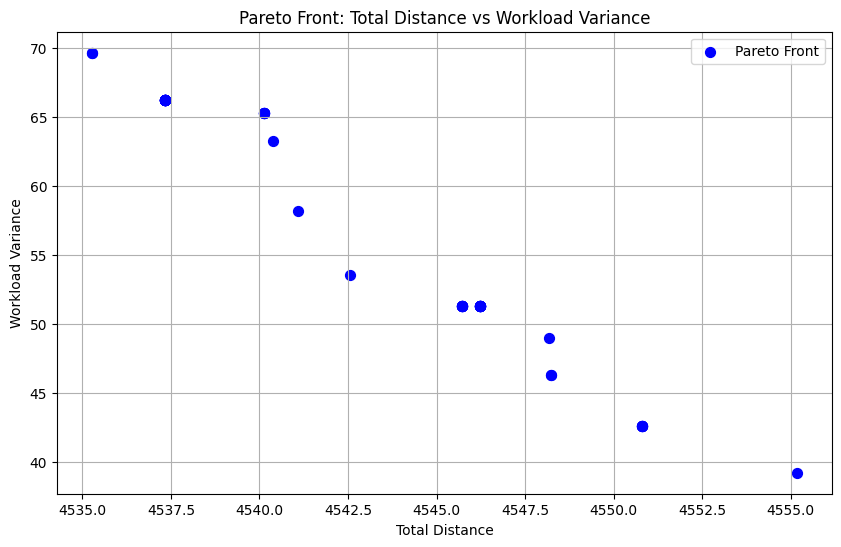

In [52]:
# Step 1: Collect total distance and workload variance for each final solution
pareto_data = []

for ind in population:
    _, total_distance, workload_variance = evaluate_fitness(ind, distance_matrix)
    pareto_data.append((total_distance, workload_variance))

# Pareto dominance check
def is_dominated(p, others):
    return any((q[0] <= p[0] and q[1] < p[1]) or (q[0] < p[0] and q[1] <= p[1]) for q in others)

# Extract non-dominated solutions (Pareto front)
pareto_front = [p for p in pareto_data if not is_dominated(p, pareto_data)]
pareto_front.sort(key=lambda x: x[0])

# # Step 2: Separate into X and Y for plotting
# distances = [p[0] for p in pareto_data]
# variances = [p[1] for p in pareto_data]

# Step 3: Plot Pareto Front
plt.figure(figsize=(10, 6))
# plt.scatter(*zip(*pareto_data), color='lightblue', label='All Solutions')
plt.scatter(*zip(*pareto_front), color='blue', label='Pareto Front', s=50)
plt.title('Pareto Front: Total Distance vs Workload Variance')
plt.xlabel('Total Distance')
plt.ylabel('Workload Variance')
plt.legend()
plt.grid(True)
plt.show()

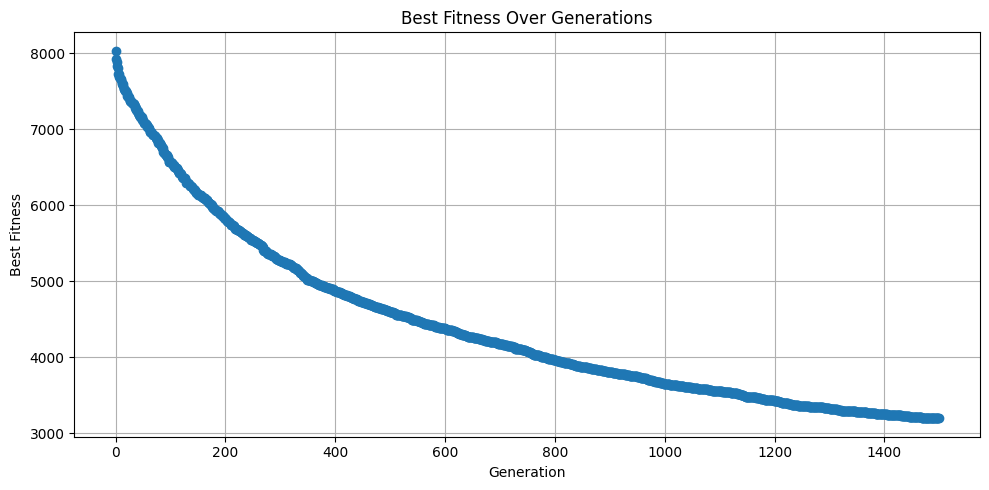

In [55]:
# Plot best fitness over generations
plt.figure(figsize=(10, 5))
plt.plot(best_fitness_over_time, marker='o', linestyle='-')
plt.title('Best Fitness Over Generations')
plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.grid(True)
plt.tight_layout()
plt.show()


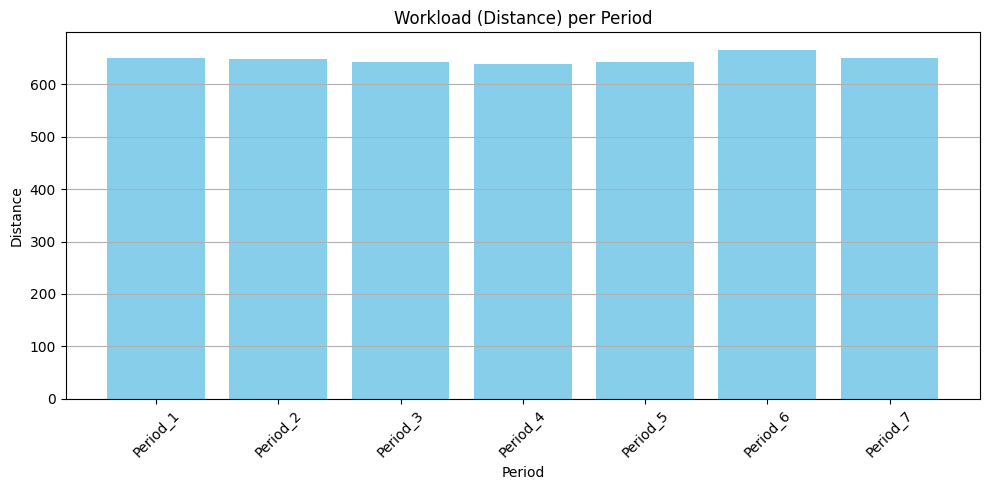

In [54]:
# Workload per period for best solution
def plot_workload_per_period(solution, distance_matrix):
    period_distances = []
    labels = []

    for period_name, route in solution.items():
        if len(route) <= 1:
            distance = 0
        else:
            distance = sum(
                distance_matrix[route[i]][route[i+1]] for i in range(len(route)-1)
            )
        period_distances.append(distance)
        labels.append(period_name)

    plt.figure(figsize=(10, 5))
    plt.bar(labels, period_distances, color='skyblue')
    plt.title('Workload (Distance) per Period')
    plt.xlabel('Period')
    plt.ylabel('Distance')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# Call the function with your best solution
plot_workload_per_period(best_solution, distance_matrix)
